In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("yasserh/titanic-dataset")
print(path)

/kaggle/input/datasets/yasserh/titanic-dataset


In [3]:
df = pd.read_csv(os.path.join(path,"Titanic-Dataset.csv"))
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df['Age'] =df['Age'].fillna(df['Age'].median())
df =df.drop('Cabin',axis=1,errors='ignore')
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df=df.drop(['Name','Ticket','PassengerId'],axis=1,errors='ignore')
df =pd.get_dummies(df,columns=['Sex','Embarked'],drop_first='True')
X=df.drop('Survived',axis=1)
y= df['Survived']

from sklearn.model_selection import train_test_split
train_X,val_X,train_y,val_y =train_test_split(X,y,random_state=0)
print(X.dtypes)
print(train_X.shape,val_X.shape)

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object
(668, 8) (223, 8)


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler = StandardScaler()
train_X_scaled = scaler.fit_transform(train_X)
val_X_scaled = scaler.transform(val_X)
model_scaled =LogisticRegression(max_iter =1000)
model_scaled.fit(train_X_scaled,train_y)
print("trained successfully")

trained successfully


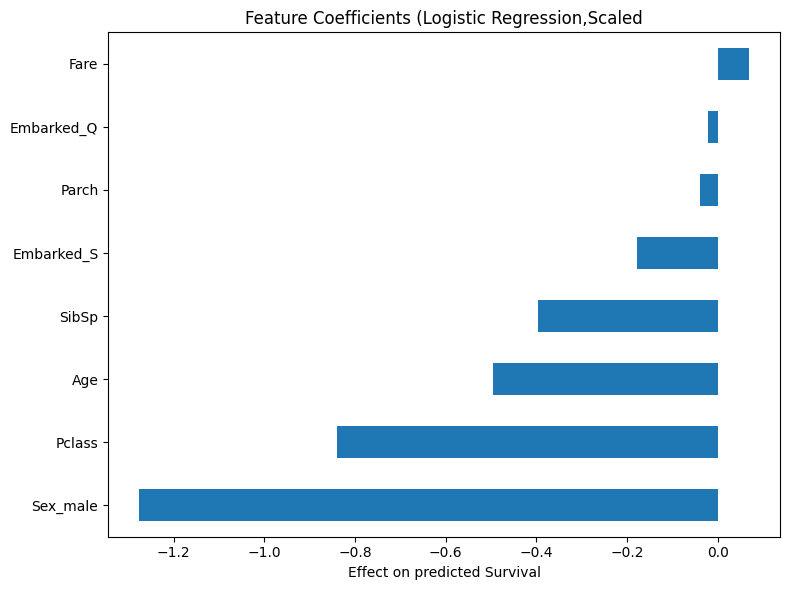

In [6]:
import matplotlib.pyplot as plt
coeffs = pd.Series(model_scaled.coef_[0],index =train_X.columns).sort_values()
coeffs.plot(kind='barh',figsize=(8,6))
plt.title('Feature Coefficients (Logistic Regression,Scaled')
plt.xlabel('Effect on predicted Survival')
plt.tight_layout()
plt.show()


In [7]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
val_predictions_scaled = model_scaled.predict(val_X_scaled)
accuracy = accuracy_score(val_y,val_predictions_scaled)
print('Accuracy:',accuracy)
print(confusion_matrix(val_y,val_predictions_scaled))
print(classification_report(val_y,val_predictions_scaled))

Accuracy: 0.7937219730941704
[[116  23]
 [ 23  61]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       139
           1       0.73      0.73      0.73        84

    accuracy                           0.79       223
   macro avg       0.78      0.78      0.78       223
weighted avg       0.79      0.79      0.79       223



In [8]:
from sklearn.tree import DecisionTreeClassifier
tree_model =DecisionTreeClassifier(random_state=0)
tree_model.fit(train_X,train_y)
tree_predictions =tree_model.predict(val_X)
print('Accuracy:',accuracy_score(val_y,tree_predictions))
print(confusion_matrix(val_y,tree_predictions))

Accuracy: 0.7892376681614349
[[119  20]
 [ 27  57]]


In [9]:
tree_model_limited =DecisionTreeClassifier(random_state=0,max_depth=4)
tree_model_limited.fit(train_X,train_y)
tree_predictions =tree_model_limited.predict(val_X)
print('Accuracy:',accuracy_score(val_y,tree_predictions))

Accuracy: 0.820627802690583
